**Library**

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.svm import SVC, LinearSVC
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline as Pipeline
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectFromModel
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
RANDOM_STATE = 42
CV = 3
N_JOBS = 1

In [ ]:
from pathlib import Path
import pandas as pd

candidates = [
    Path('data') / 'alzheimers_preprocessed.csv',
    Path('alzheimers_preprocessed.csv'),
]

PREPROCESSED_DATA_PATH = None
for p in candidates:
    if p.exists():
        PREPROCESSED_DATA_PATH = p
        break

if PREPROCESSED_DATA_PATH is None:
    raise FileNotFoundError(
        "Không tìm thấy alzheimers_preprocessed.csv trong 'data/' "
        "hoặc cùng thư mục hiện tại. Hãy kiểm tra lại."
    )

df = pd.read_csv(PREPROCESSED_DATA_PATH)

In [ ]:
df = pd.read_csv(PREPROCESSED_DATA_PATH)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   float64
 1   Gender                     2149 non-null   int64  
 2   EducationLevel             2149 non-null   int64  
 3   BMI                        2149 non-null   float64
 4   Smoking                    2149 non-null   int64  
 5   AlcoholConsumption         2149 non-null   float64
 6   PhysicalActivity           2149 non-null   float64
 7   DietQuality                2149 non-null   float64
 8   SleepQuality               2149 non-null   float64
 9   FamilyHistoryAlzheimers    2149 non-null   int64  
 10  CardiovascularDisease      2149 non-null   int64  
 11  Diabetes                   2149 non-null   int64  
 12  Depression                 2149 non-null   int64  
 13  HeadInjury                 2149 non-null   int64

In [ ]:
if 'Diagnosis' not in df.columns:
    raise ValueError("Thiếu cột Diagnosis trong file dữ liệu đã tiền xử lý.")

y = df['Diagnosis']
X = df.drop(columns=['Diagnosis'])
X_encoded = X.copy()

print("Đang dùng dữ liệu đầu ra từ data_processing.ipynb:")
print(f"- Input file: {PREPROCESSED_DATA_PATH.name}")
print(f"- Feature shape: {X_encoded.shape}")

Đang dùng dữ liệu đầu ra từ data_processing.ipynb:
- Input file: alzheimers_preprocessed.csv
- Feature shape: (2149, 35)


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42, stratify=y
)

n_features = X_train.shape[1]
print("Số features:", n_features)

Số features: 35


Testing scalers:  33%|███▎      | 1/3 [00:03<00:06,  3.21s/it]

 PowerTransformer: 0.8081


Testing scalers:  67%|██████▋   | 2/3 [00:04<00:01,  1.85s/it]

 RobustScaler: 0.8125


Testing scalers: 100%|██████████| 3/3 [00:04<00:00,  1.64s/it]


 StandardScaler: 0.8091
Scaler: RobustScaler


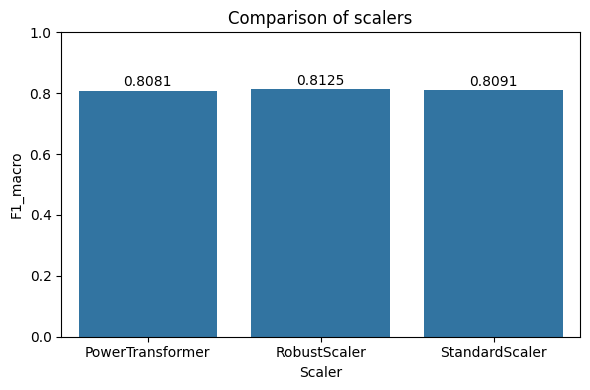

In [ ]:

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

svm = SVC(
    kernel='rbf',
    class_weight='balanced',
    random_state=42,
    max_iter=int(10000),
    tol=1e-3
)

scalers_to_test = {
    'PowerTransformer': PowerTransformer(),
    'RobustScaler': RobustScaler(),
    'StandardScaler': StandardScaler(),
}

scaler_results = {}
for scaler_name, scaler in tqdm(scalers_to_test.items(), desc="Testing scalers"):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', scaler),
        ('svm', svm)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    scaler_results[scaler_name] = scores.mean()
    tqdm.write(f" {scaler_name}: {scores.mean():.4f}")

best_scaler = max(scaler_results.keys(), key=lambda x: scaler_results[x])
best_scaler_obj = scalers_to_test[best_scaler]

print(f"Scaler: {best_scaler}")

def add_bar_labels(ax, fmt="{:.4f}", offset=0.005):
    for p in ax.patches:
        value = p.get_height()
        ax.text(
            p.get_x() + p.get_width() / 2,
            value + offset,
            fmt.format(value),
            ha="center",
            va="bottom"
        )

scaler_df = pd.DataFrame(
    list(scaler_results.items()),
    columns=["Scaler", "F1_macro"]
)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=scaler_df, x="Scaler", y="F1_macro")
plt.title("Comparison of scalers")
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

**Sample**

Testing sampling:  50%|█████     | 1/2 [00:01<00:01,  1.10s/it]

 No Sampling: 0.8125


Testing sampling: 100%|██████████| 2/2 [00:01<00:00,  1.05it/s]

 SMOTE: 0.8147
Sampling: SMOTE


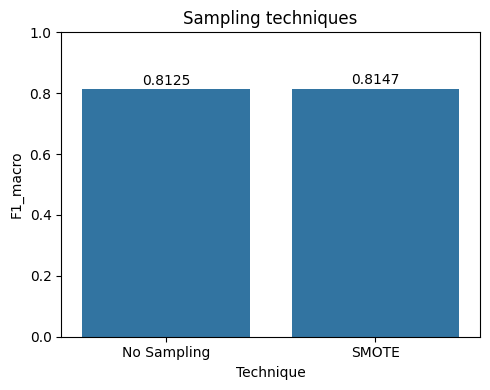

In [ ]:

imbalance_techniques = {
    'No Sampling': None,
    'SMOTE': SMOTE(random_state=42)
}

imbalance_results = {}
for technique_name, technique in tqdm(imbalance_techniques.items(), desc="Testing sampling"):
    pipe = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler_obj),
        ('sampler', technique),
        ('svm', svm)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    imbalance_results[technique_name] = scores.mean()
    tqdm.write(f" {technique_name}: {scores.mean():.4f}")

best_technique_name = max(imbalance_results.keys(), key=lambda x: imbalance_results[x])
best_technique = imbalance_techniques[best_technique_name]

print(f"Sampling: {best_technique_name}")

imb_df = pd.DataFrame(
    list(imbalance_results.items()),
    columns=["Technique", "F1_macro"]
)

plt.figure(figsize=(5,4))
ax = sns.barplot(data=imb_df, x="Technique", y="F1_macro")
plt.title("Sampling techniques")
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

**SVM Models**

Comparing SVC / LinearSVC / SGD:  67%|██████▋   | 2/3 [00:00<00:00,  2.85it/s]

 SVC_linear: 0.8238 (+/- 0.0403)
 LinearSVC: 0.8127 (+/- 0.0313)


Comparing SVC / LinearSVC / SGD: 100%|██████████| 3/3 [00:00<00:00,  3.07it/s]


 SGD_hinge: 0.7974 (+/- 0.0491)
Best SVM-like implementation: SVC_linear


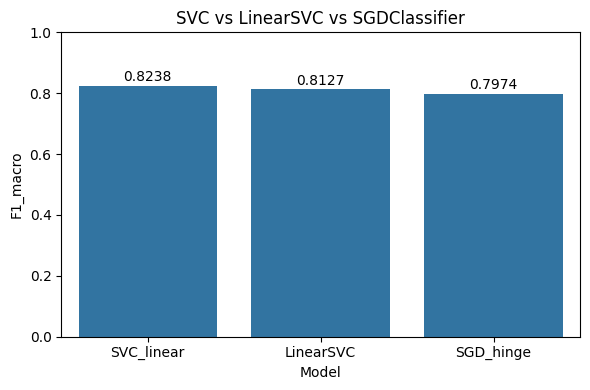

In [ ]:

svm_like_models = {
    'SVC_linear': SVC(
        kernel='linear',
        class_weight='balanced',
        random_state=42,
        max_iter=10000,
        tol=1e-3
    ),
    'LinearSVC': LinearSVC(
        class_weight='balanced',
        random_state=42,
        max_iter=20000
    ),
    'SGD_hinge': SGDClassifier(
        loss='hinge',
        alpha=1e-4,
        class_weight='balanced',
        random_state=42,
        max_iter=20000,
        tol=1e-3
    )
}

svm_like_results = {}

for name, clf in tqdm(svm_like_models.items(), desc="Comparing SVC / LinearSVC / SGD"):
    if best_technique is None:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('svm', clf)
        ])
    else:
        pipe = ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('sampler', best_technique),
            ('svm', clf)
        ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    svm_like_results[name] = scores.mean()
    tqdm.write(f" {name}: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

best_svm_like_name = max(svm_like_results.keys(), key=lambda x: svm_like_results[x])
best_svm_like_model = svm_like_models[best_svm_like_name]

print(f"Best SVM-like implementation: {best_svm_like_name}")

svm_like_df = pd.DataFrame(
    list(svm_like_results.items()),
    columns=["Model", "F1_macro"]
)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=svm_like_df, x="Model", y="F1_macro")
plt.title("SVC vs LinearSVC vs SGDClassifier")
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()


**Kernel**

Testing kernels:  33%|███▎      | 1/3 [00:00<00:00,  2.12it/s]

 LINEAR kernel: 0.8185 (+/- 0.0302)


Testing kernels:  67%|██████▋   | 2/3 [00:01<00:00,  1.94it/s]

 RBF kernel: 0.8125 (+/- 0.0451)


Testing kernels: 100%|██████████| 3/3 [00:01<00:00,  2.01it/s]

 POLY kernel: 0.7994 (+/- 0.0263)

Best kernel: linear


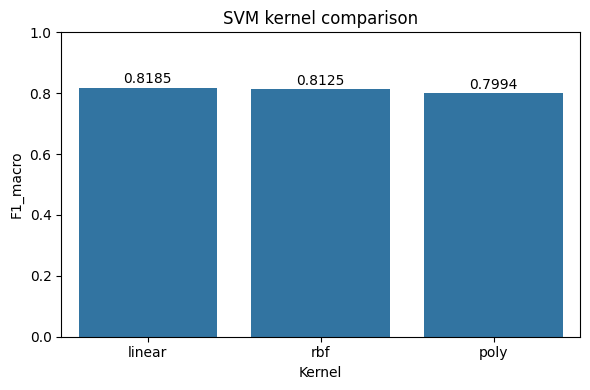

In [ ]:

kernels_to_test = ['linear', 'rbf', 'poly']
kernel_results = {}

for kernel in tqdm(kernels_to_test, desc="Testing kernels"):
    if kernel == 'poly':
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('svm', SVC(kernel=kernel, degree=3, class_weight='balanced', random_state=42))
        ])
    else:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('svm', SVC(kernel=kernel, class_weight='balanced', random_state=42))
        ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    kernel_results[kernel] = scores.mean()
    tqdm.write(f" {kernel.upper()} kernel: {scores.mean():.4f} (+/- {scores.std() * 2:.4f})")

best_kernel = max(kernel_results.keys(), key=lambda x: kernel_results[x])

print(f"\nBest kernel: {best_kernel}")
svm = SVC(
    kernel=best_kernel,
    class_weight='balanced',
    random_state=42,
    max_iter=int(10000),
    tol=1e-3
)

kernel_df = pd.DataFrame(
    list(kernel_results.items()),
    columns=["Kernel", "F1_macro"]
)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=kernel_df, x="Kernel", y="F1_macro")
plt.title("SVM kernel comparison")
plt.ylim(0, 1)
add_bar_labels(ax)
plt.tight_layout()
plt.show()

**Feature**

Testing features:  25%|██▌       | 1/4 [00:00<00:00,  3.25it/s]

 17 features: 0.8177 (+/- 0.0319)


Testing features:  50%|█████     | 2/4 [00:00<00:00,  3.01it/s]

 24 features: 0.8175 (+/- 0.0326)


Testing features:  75%|███████▌  | 3/4 [00:01<00:00,  2.72it/s]

 31 features: 0.8225 (+/- 0.0323)


Testing features: 100%|██████████| 4/4 [00:01<00:00,  2.63it/s]

 35 features: 0.8185 (+/- 0.0302)
Features: 31


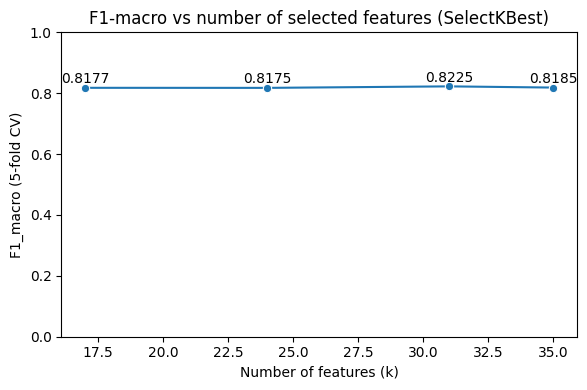

In [ ]:
original_features = X_train.shape[1]
feature_counts = [int(original_features * 0.5), int(original_features * 0.7), int(original_features * 0.9), original_features]

feature_results = {}
for k in tqdm(feature_counts, desc="Testing features"):
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler_obj),
        ('selector', SelectKBest(score_func=f_classif, k=k)),
        ('svm', svm)
    ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro', n_jobs=-1)
    feature_results[k] = scores.mean()
    tqdm.write(f" {k} features: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_features = max(feature_results.keys(), key=lambda x: feature_results[x])

print(f"Features: {best_features}")

feat_df = pd.DataFrame(
    list(feature_results.items()),
    columns=["k_features", "F1_macro"]
).sort_values("k_features")

plt.figure(figsize=(6,4))
ax = sns.lineplot(data=feat_df, x="k_features", y="F1_macro", marker='o')
plt.title("F1-macro vs number of selected features (SelectKBest)")
plt.xlabel("Number of features (k)")
plt.ylabel("F1_macro (5-fold CV)")
plt.ylim(0, 1)

for x, y in zip(feat_df["k_features"], feat_df["F1_macro"]):
    ax.text(x, y + 0.005, f"{y:.4f}", ha="center", va="bottom")

plt.tight_layout()
plt.show()

**Selector**

Comparing feature selectors:  33%|███▎      | 1/3 [00:00<00:01,  1.78it/s]

 SelectKBest_f_classif: 0.8150 (+/- 0.0272)


Comparing feature selectors:  67%|██████▋   | 2/3 [00:01<00:00,  1.69it/s]

 L1_LogReg: 0.8182 (+/- 0.0419)


Comparing feature selectors: 100%|██████████| 3/3 [00:01<00:00,  1.73it/s]

 L1_LinearSVC: 0.8170 (+/- 0.0352)
Best feature selector: L1_LogReg


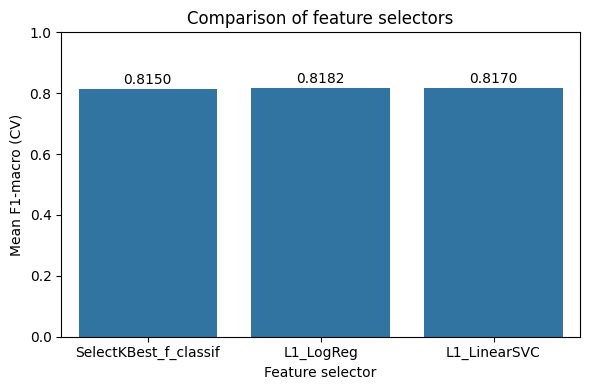

In [ ]:

selector_candidates = {
    'SelectKBest_f_classif': SelectKBest(score_func=f_classif, k=best_features),
    'L1_LogReg': SelectFromModel(
        LogisticRegression(
            penalty='l1',
            solver='liblinear',
            random_state=42
        )
    ),
    'L1_LinearSVC': SelectFromModel(
        LinearSVC(
            C=0.1,
            penalty='l1',
            dual=False,
            random_state=42
        )
    )
}

selector_cv_results = {}

for name, selector in tqdm(selector_candidates.items(), desc="Comparing feature selectors"):
    if best_technique is None:
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('selector', selector),
            ('svm', svm)
        ])
    else:
        pipe = ImbPipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', best_scaler_obj),
            ('selector', selector),
            ('sampler', best_technique),
            ('svm', svm)
        ])

    scores = cross_val_score(pipe, X_train, y_train, cv=cv,
                             scoring='f1_macro', n_jobs=-1)
    selector_cv_results[name] = scores.mean()
    tqdm.write(f" {name}: {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

best_selector_name = max(selector_cv_results.keys(),
                         key=lambda x: selector_cv_results[x])
best_selector = selector_candidates[best_selector_name]

print(f"Best feature selector: {best_selector_name}")

selector_df = pd.DataFrame(
    list(selector_cv_results.items()),
    columns=["Selector", "F1_macro"]
)

plt.figure(figsize=(6,4))
ax = sns.barplot(data=selector_df, x="Selector", y="F1_macro")
plt.title("Comparison of feature selectors")
plt.ylim(0, 1)
plt.xlabel("Feature selector")
plt.ylabel("Mean F1-macro (CV)")
add_bar_labels(ax)
plt.tight_layout()
plt.show()

**Tuning**


=== Tuning pipeline ===
Fitting 5 folds for each of 13 candidates, totalling 65 fits
Best params: {'svm__C': np.float64(3.1622776601683795)}
Best CV F1-macro: 0.8221

--- Test set performance ---
Accuracy: 0.8163
F1-macro: 0.8060

Classification report:
               precision    recall  f1-score   support

           0       0.90      0.81      0.85       278
           1       0.70      0.83      0.76       152

    accuracy                           0.82       430
   macro avg       0.80      0.82      0.81       430
weighted avg       0.83      0.82      0.82       430



/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=10000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


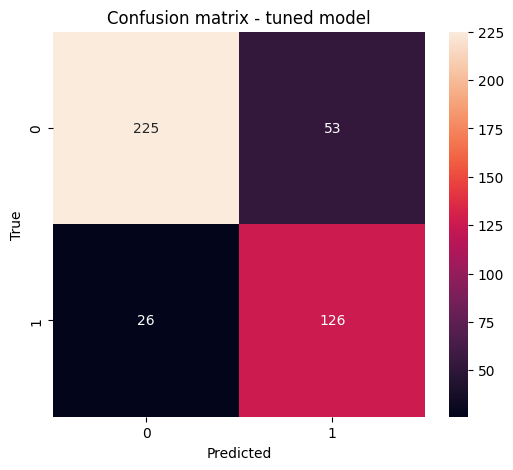


=== Summary ===
Baseline  -> Accuracy: 0.8163, F1-macro: 0.8060

>>> Best overall model:
                    Type:  Baseline
             Best_kernel:  linear
             Best_scaler:  RobustScaler
           Best_features:  31
          Best_technique:  SMOTE


In [ ]:

if best_kernel == 'linear':
    param_grid = {
    'svm__C': np.logspace(-3, 3, 13)
}
elif best_kernel == 'rbf':
    param_grid = {
        'svm__C': np.logspace(-3, 3, 13),
        'svm__gamma': [0.001, 0.01, 0.1, 1, 'scale']
    }
elif best_kernel == 'poly':
    param_grid = {
        'svm__C': [0.1, 1, 10],
        'svm__gamma': ['scale', 0.01, 0.1, 1],
        'svm__degree': [2, 3, 4]
    }
else:
    param_grid = {
        'svm__C': np.logspace(-3, 3, 13),
        'svm__gamma': ['scale', 0.01, 0.1, 1]
    }

"""Tuning"""

if best_technique is None:
    pipe_main = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler_obj),
        ('selector', best_selector),
        ('svm', svm)
    ])
else:
    pipe_main = ImbPipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', best_scaler_obj),
        ('selector', best_selector),
        ('sampler', best_technique),
        ('svm', svm)
    ])

if best_selector_name == 'SelectKBest_f_classif':
    selector_k_candidates = [best_features]
    param_grid_main = {
        'selector__k': selector_k_candidates,
        **param_grid
    }
else:
    param_grid_main = param_grid

grid_main = GridSearchCV(
    pipe_main,
    param_grid=param_grid_main,
    cv=cv,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=2
)

print("\n=== Tuning pipeline ===")
grid_main.fit(X_train, y_train)

best_model_tuned = grid_main.best_estimator_
print("Best params:", grid_main.best_params_)
print(f"Best CV F1-macro: {grid_main.best_score_:.4f}")

y_pred_main = best_model_tuned.predict(X_test)
acc_main = accuracy_score(y_test, y_pred_main)
f1_main = f1_score(y_test, y_pred_main, average='macro')

print("\n--- Test set performance ---")
print(f"Accuracy: {acc_main:.4f}")
print(f"F1-macro: {f1_main:.4f}")
print("\nClassification report:\n", classification_report(y_test, y_pred_main))

cm_main = confusion_matrix(y_test, y_pred_main)
plt.figure(figsize=(6,5))
sns.heatmap(cm_main, annot=True, fmt='d')
plt.title('Confusion matrix - tuned model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

best_model = best_model_tuned
best_type = "Baseline"

print("\n=== Summary ===")
print(f"Baseline  -> Accuracy: {acc_main:.4f}, F1-macro: {f1_main:.4f}")
print("\n>>> Best overall model:")
print(f"                    Type: ", best_type)
print(f"             Best_kernel: ", best_kernel)
print(f"             Best_scaler: ", best_scaler)
print(f"           Best_features: ", best_features)
print(f"          Best_technique: ", best_technique_name)


**Evaluate**

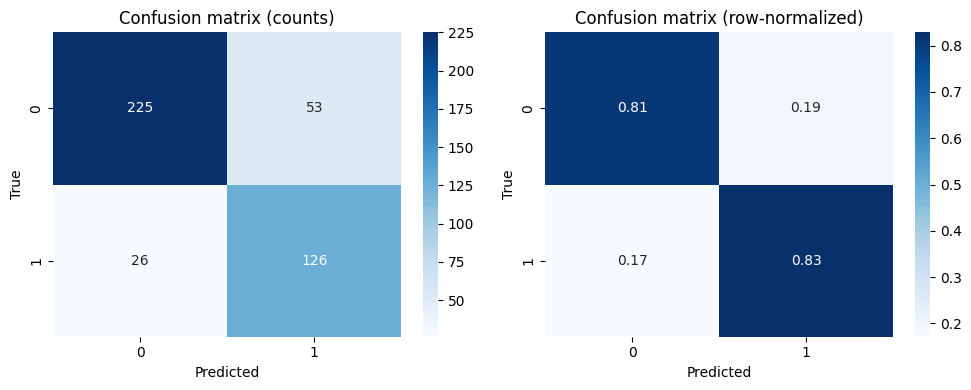

In [ ]:

y_pred_best = best_model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

cm_norm = cm / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(1, 2, figsize=(10,4))

sns.heatmap(cm, annot=True, fmt='d', cmap="Blues", ax=ax[0])
ax[0].set_title("Confusion matrix (counts)")
ax[0].set_xlabel("Predicted")
ax[0].set_ylabel("True")

sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues", ax=ax[1])
ax[1].set_title("Confusion matrix (row-normalized)")
ax[1].set_xlabel("Predicted")
ax[1].set_ylabel("True")

plt.tight_layout()
plt.show()
